# Feature Engineering Starter

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [151]:
df = pd.read_csv('titanic_data_updated.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [152]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
# df.drop(['Cabin'], axis=1, inplace=True)

In [153]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [154]:
X = df.drop(['Survived'], axis=1)

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [155]:
y = df['Survived']

y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

# Train Test Split

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [157]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [158]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


# Handling Missing Values

In [159]:
# missing

df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

# Numerical Missing value Imputation using Pandas

In [160]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [161]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [162]:
# mean imputation

age_mean = X_train['Age'].mean()

X_train['Age_mean_imputor'] = X_train['Age'].fillna(age_mean)

X_test['Age_mean_imputor'] = X_train['Age'].fillna(age_mean)

In [163]:
# median imputation

age_median = X_train['Age'].median()

X_train['Age_median_imputor'] = X_train['Age'].fillna(age_median)

X_test['Age_median_imputor'] = X_train['Age'].fillna(age_median)

In [164]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Age_mean_imputor,Age_median_imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


<Axes: xlabel='Age_mean_imputor', ylabel='Density'>

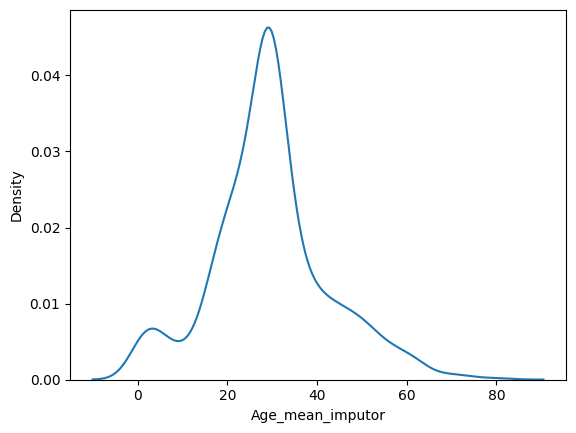

In [165]:
sns.kdeplot(data = X_train,
           x = 'Age_mean_imputor')

<Axes: xlabel='Age_median_imputor', ylabel='Density'>

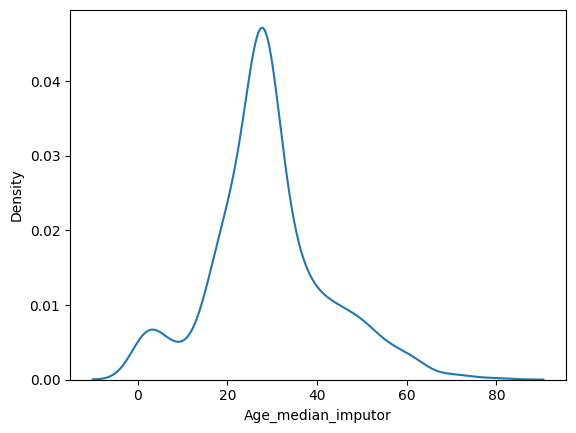

In [166]:
sns.kdeplot(data = X_train,
           x = 'Age_median_imputor')

# Numerical Missing Values Imputation using Simple Imputer

In [167]:
age_imputer = SimpleImputer(missing_values = np.nan, 
                            strategy = 'mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputor.transform(X_train[['Age']])

In [168]:
X_train.drop(['Age_mean_imputor', 'Age_median_imputor'], 
             axis=1, 
             inplace=True)

X_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [169]:
X_test['Age'] = age_imputor.transform(X_test[['Age']])

In [170]:
X_test.drop(['Age_mean_imputor', 'Age_median_imputor'], 
             axis=1, 
             inplace=True)

X_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [171]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


# Categorical Value Imputation with Mode Value

In [178]:
emburd_impoter = SimpleImputer(missing_values=np.nan,
                              strategy='most_frequent')

emburd_impoter.fit(X_train[['Embarked']])

X_train['Embarked'] = emburd_impoter.transform(X_train[['Embarked']]).ravel()

X_test['Embarked'] = emburd_impoter.transform(X_test[['Embarked']]).ravel()

In [179]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

#  Categorical Value Imputation with Missing string and Indicator

<Axes: xlabel='Cabin', ylabel='count'>

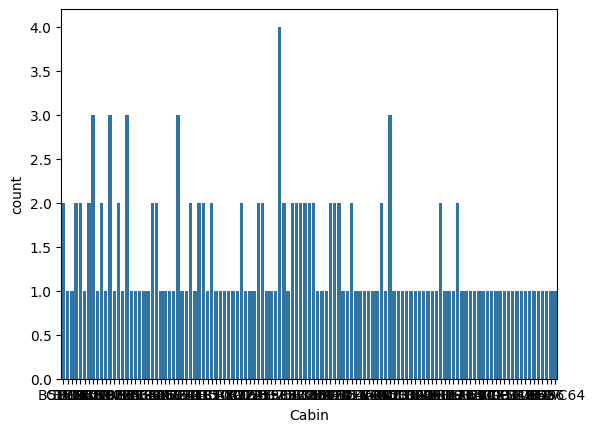

In [180]:
sns.countplot(data=X_train,
             x=X_train['Cabin'])

In [181]:
cabin_impoter = SimpleImputer(missing_values=np.nan,
                              strategy='constant',
                              fill_value='Missing',
                              add_indicator=True)

cabin_impoter.fit(X_train[['Cabin']])

X_train[['Cabin', 'Cabin_value_indicator']] = cabin_impoter.transform(X_train[['Cabin']])

X_test[['Cabin', 'Cabin_value_indicator']] = cabin_impoter.transform(X_test[['Cabin']])

In [182]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_value_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [183]:
X_test.isnull().sum()

Pclass                   0
Sex                      0
Age                      0
SibSp                    0
Parch                    0
Fare                     0
Cabin                    0
Embarked                 0
Cabin_value_indicator    0
dtype: int64